In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [161]:
df = pd.read_csv(
    'dados_reduzidos.csv',
    sep=';',
    decimal=',',
)
df.head()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,...,bairro,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,32,2,1,180.0,0,1,0,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,SÃO MATEUS,PRATA,6822.823684,-23.583879,-46.417548
1,734,221110,43,2,1,250.0,0,1,0,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4682.709841,-23.543535,-46.425492
2,738,219990,43,1,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
3,753,219990,43,2,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
4,924,220000,41,2,1,300.0,0,1,1,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,3313.918703,-23.557799,-46.443523


In [162]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2499 non-null   int64  
 1   valor_total       2499 non-null   int64  
 2   area_util         2499 non-null   int64  
 3   quartos           2499 non-null   int64  
 4   vagas             2499 non-null   int64  
 5   valor_condominio  2264 non-null   float64
 6   suites            2499 non-null   int64  
 7   banheiros         2499 non-null   int64  
 8   piscina           2499 non-null   int64  
 9   academia          2499 non-null   int64  
 10  quadra            2499 non-null   int64  
 11  link              2499 non-null   str    
 12  bairro            2499 non-null   str    
 13  qtd_dados_bairro  2492 non-null   float64
 14  media_idh         2499 non-null   float64
 15  expectativa_vida  2499 non-null   float64
 16  renda_percapita   2499 non-null   float64
 17  estaca

In [163]:
df.describe()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,quadra,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,dist,lat,lon
count,2499.000000,2.499000e+03,2499.000000,2499.000000,2499.000000,2264.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2492.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000,2499.000000
mean,1290.477791,5.480852e+05,71.316927,2.276911,1.226491,1720.326413,0.647459,1.742297,0.370948,0.165266,0.306523,21.928973,0.792821,77.035595,1583.835864,2850.631882,-23.564247,-46.615783
std,740.952704,5.544487e+05,44.756816,0.628384,1.077428,28048.547320,0.805409,1.022180,0.483155,0.371495,0.461142,9.753988,0.057991,2.270557,1108.707809,2740.544877,0.067111,0.101202
min,1.000000,8.000000e+04,22.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.692258,72.411290,522.515294,31.324895,-23.882700,-46.805753
25%,649.500000,2.650000e+05,49.000000,2.000000,1.000000,350.000000,0.000000,1.000000,0.000000,0.000000,0.000000,15.000000,0.747778,75.376296,863.321429,926.379634,-23.603639,-46.692986
50%,1292.000000,3.800000e+05,60.000000,2.000000,1.000000,486.000000,0.000000,1.000000,0.000000,0.000000,0.000000,21.000000,0.788200,77.182500,1243.473077,2030.330924,-23.553274,-46.634285
75%,1932.500000,5.985000e+05,74.000000,3.000000,1.000000,650.000000,1.000000,2.000000,1.000000,0.000000,1.000000,28.000000,0.826400,78.438750,1788.620000,3844.249552,-23.513279,-46.541624
max,2570.000000,1.200000e+07,640.000000,5.000000,39.000000,857000.000000,4.000000,8.000000,1.000000,1.000000,1.000000,51.000000,0.944667,81.950000,6721.230000,26101.126560,-23.402091,-46.376155


O conjunto de dados é composto por 2.499 registros e 21 atributos. Embora a quantidade de variáveis não seja elevada, é importante avaliar a relevância e a qualidade das informações fornecidas por cada atributo em relação à variável-alvo que se deseja predizer. Durante a análise exploratória, foram identificados valores ausentes nos atributos valor_condominio e qtd_dados_bairro, com 235 e 7 registros nulos, respectivamente. Dessa forma, torna-se necessária a definição de uma estratégia de tratamento desses dados, como imputação ou remoção dos registros afetados. Também foram observados outliers na variável valor_total.  Além disso, os atributos media_idh e expectativa_vida podem ser transformados em variáveis categóricas intervalares permitindo a criação de faixas que facilitem a interpretação dos dados e a utilização por determinados algoritmos.

In [164]:
df = pd.read_csv(
    'dados_reduzidos.csv',
    sep=';',
    decimal=',',
)
df.head()

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,...,bairro,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,32,2,1,180.0,0,1,0,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,SÃO MATEUS,PRATA,6822.823684,-23.583879,-46.417548
1,734,221110,43,2,1,250.0,0,1,0,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4682.709841,-23.543535,-46.425492
2,738,219990,43,1,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
3,753,219990,43,2,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
4,924,220000,41,2,1,300.0,0,1,1,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,3313.918703,-23.557799,-46.443523


In [165]:
#quantidade de valores nulos
print(df.isnull().sum())

id                    0
valor_total           0
area_util             0
quartos               0
vagas                 0
valor_condominio    235
suites                0
banheiros             0
piscina               0
academia              0
quadra                0
link                  0
bairro                0
qtd_dados_bairro      7
media_idh             0
expectativa_vida      0
renda_percapita       0
estacao_prox          0
linha_prox            0
dist                  0
lat                   0
lon                   0
dtype: int64


In [166]:
#Printa os valores nulos
print(df[df["valor_condominio"].isnull()])
print(df[df["qtd_dados_bairro"].isnull()])

        id  valor_total  area_util  quartos  vagas  valor_condominio  suites  \
10     954       170000         56        2      1               NaN       0   
15    1025       211900         38        2      0               NaN       0   
25    1035       170000         48        2      1               NaN       0   
32    1044       199000         26        1      0               NaN       0   
50    1323       219900         39        2      0               NaN       0   
...    ...          ...        ...      ...    ...               ...     ...   
2396  1686       254000         38        2      1               NaN       0   
2410  1210       782612         67        2      1               NaN       2   
2457  2080       300000         70        2      1               NaN       1   
2462  2086       270000         54        2      1               NaN       1   
2494  2232       400000         61        1      0               NaN       0   

      banheiros  piscina  academia  ...

In [167]:
#Substitui os valores nulos pela mediana

df["valor_condominio"] = df["valor_condominio"].fillna(
    df["valor_condominio"].median()
)

df["qtd_dados_bairro"] = df["qtd_dados_bairro"].fillna(
    df["qtd_dados_bairro"].median()
)

In [168]:
# análise de outliers

Q1 = df["valor_total"].quantile(0.25)
Q3 = df["valor_total"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[
    (df["valor_total"] < lim_inf) |
    (df["valor_total"] > lim_sup)
]

print("Quantidade de outliers:", len(outliers))

Quantidade de outliers: 236


In [169]:
df["valor_m2"] = df["valor_total"] / df["area_util"]

Q1 = df["valor_m2"].quantile(0.25)
Q3 = df["valor_m2"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_m2 = df[
    (df["valor_m2"] < lim_inf) |
    (df["valor_m2"] > lim_sup)
]

print("Outliers valor/m²:", len(outliers_m2))

Outliers valor/m²: 93


In [170]:
# Discretização do IDH
df["faixa_idh"] = pd.cut(
    df["media_idh"],
    bins=[0, 0.55, 0.70, 0.80, 1.0],
    labels=[
        "Muito Baixo",
        "Médio",
        "Alto",
        "Muito Alto"
    ]
)

# Discretização da expectativa de vida

df["faixa_expectativa_vida"] = pd.cut(
    df["expectativa_vida"],
    bins=[0, 65, 75, 85, 100],
    labels=[
        "Baixa",
        "Média",
        "Alta",
        "Muito Alta"
    ]
)

In [171]:
scaler = MinMaxScaler()

colunas = ["valor_total", "valor_condominio", "area_util"]

df[colunas] = scaler.fit_transform(df[colunas])

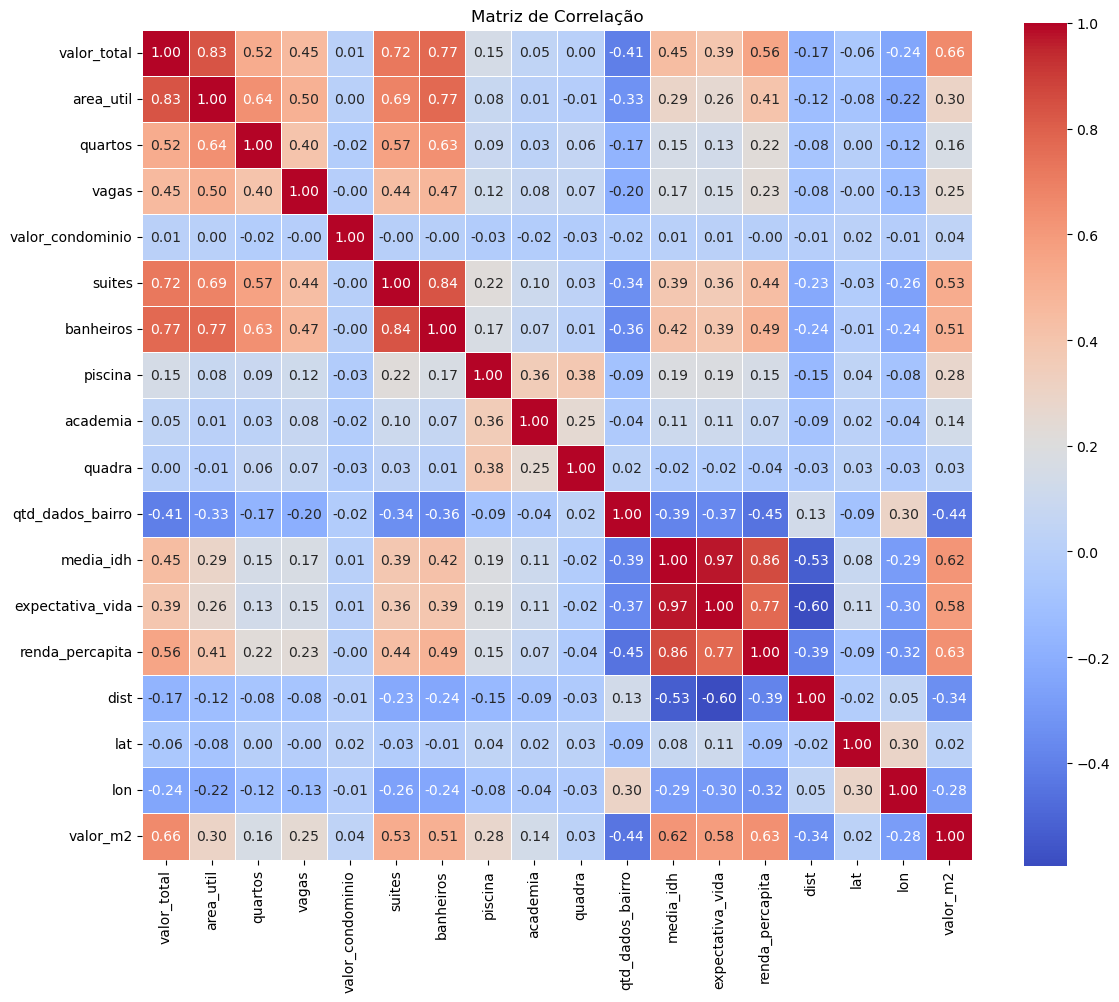

In [172]:
corr = df.drop(columns=["id"]).corr(numeric_only=True)
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()